# Classification Metrics

<div style="background-color:#1e293b;padding:15px;border-left:6px solid #38bdf8;color:#e2e8f0">

Accuracy tells you how often a model is right overall. But a churn model that correctly identifies 73.5% of customers simply by predicting nobody churns is not useful — it misses every actual churner.

The <b>confusion matrix</b> breaks predictions into four categories (TP, TN, FP, FN) and is the foundation for every other classification metric. In this notebook you will compute accuracy, precision, recall, and F1 from first principles, then verify each with sklearn, and visualise how they shift as you change the classification threshold.

</div>

---
## Step 1: Load Data and Train a Quick Model

We will reuse the Telco Customer Churn setup from the previous tutorial — the same four numerical features, the same split. The goal here is evaluation, not training, so we build the model in a few lines and move on.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
)

df = pd.read_csv('telco_churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges'])
y = (df['Churn'] == 'Yes').astype(int).values
X = df[['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_sc, y_train)

y_pred  = model.predict(X_test_sc)
y_proba = model.predict_proba(X_test_sc)[:, 1]

print(f'Test set size: {len(y_test)}  |  Positive rate: {y_test.mean():.3f}')
print(f'Predicted positive rate: {y_pred.mean():.3f}')

Test set size: 1407  |  Positive rate: 0.266
Predicted positive rate: 0.193


---
## Step 2: The Confusion Matrix

The confusion matrix shows every combination of actual class vs. predicted class:

|  | Predicted Not Churned | Predicted Churned |
|--|----------------------|------------------|
| **Actual Not Churned** | True Negative (TN) | False Positive (FP) |
| **Actual Churned** | False Negative (FN) | True Positive (TP) |

- **TP**: Correctly predicted as churned
- **TN**: Correctly predicted as not churned
- **FP**: Predicted churned, but actually stayed (Type I error)
- **FN**: Predicted not churned, but actually left (Type II error)

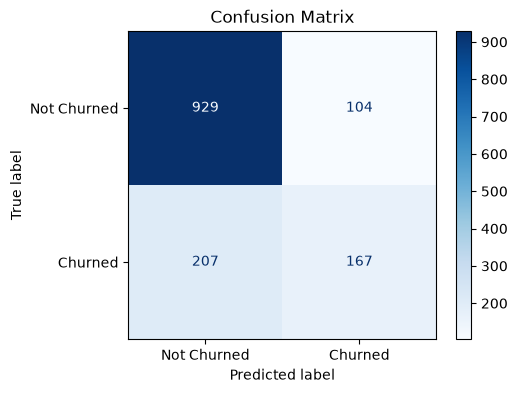

TN (correctly kept):    929
FP (false alarm):       104
FN (missed churner):    207
TP (caught churner):    167


In [5]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['Not Churned', 'Churned']).plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'TN (correctly kept):    {tn}')
print(f'FP (false alarm):       {fp}')
print(f'FN (missed churner):    {fn}')
print(f'TP (caught churner):    {tp}')

---
## Step 3: Accuracy, Precision, Recall, F1

**Accuracy** = (TP + TN) / total
— What fraction of all predictions are correct? Good for balanced datasets; misleading when one class dominates.

**Precision** = TP / (TP + FP)
— Of all the customers we flagged as churners, what fraction actually churned?
Important when **false positives are costly** (e.g. sending a costly retention offer to someone who wasn't going to leave).

**Recall** = TP / (TP + FN)
— Of all customers who actually churned, what fraction did we catch?
Important when **false negatives are` costly** (e.g. missing a churner who then leaves and is hard to win back).

**F1 score** = 2 × (Precision × Recall) / (Precision + Recall)
— The harmonic mean of precision and recall. Useful when you care about both and want a single number.

In [12]:
# Compute manually from TP/TN/FP/FN
accuracy  = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall    = tp / (tp + fn)
f1        = 2 * (precision * recall) / (precision + recall)
fpr_val   = fp / (fp + tn)   # false positive rate -- how often we falsely flag a loyal customer

print('Computed from confusion matrix:')
print(f'  Accuracy:            {accuracy:.4f}')
print(f'  Precision:           {precision:.4f}')
print(f'  Recall:              {recall:.4f}')
print(f'  F1 Score:            {f1:.4f}')
print(f'  False Positive Rate: {fpr_val:.4f}')

# Verify with sklearn
print('\nsklearn verification:')
print(f'  Accuracy:  {accuracy_score(y_test, y_pred):.4f}')
print(f'  Precision: {precision_score(y_test, y_pred):.4f}')
print(f'  Recall:    {recall_score(y_test, y_pred):.4f}')
print(f'  F1 Score:  {f1_score(y_test, y_pred):.4f}')

Computed from confusion matrix:
  Accuracy:            0.7790
  Precision:           0.6162
  Recall:              0.4465
  F1 Score:            0.5178
  False Positive Rate: 0.1007

sklearn verification:
  Accuracy:  0.7790
  Precision: 0.6162
  Recall:    0.4465
  F1 Score:  0.5178


---
## Step 4: The Threshold Trade-off

The model outputs a probability between 0 and 1 for each customer. The **threshold** (default 0.5) decides when to predict 'churned': if P(churn) ≥ threshold, predict positive.

- **Lower threshold**: the model flags more customers as churners → higher recall (catches more real churners), lower precision (more false alarms)
- **Higher threshold**: the model only flags confident churners → higher precision, lower recall

There is no universally right threshold. The choice depends on the relative cost of FP vs FN in your business context.

In [10]:
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
print(f'{'Threshold':>10} {'Precision':>10} {'Recall':>10} {'F1':>8} {'Flagged':>8}')
print('-' * 52)
for t in thresholds:
    yp = (y_proba >= t).astype(int)
    p = precision_score(y_test, yp, zero_division=0)
    r = recall_score(y_test, yp)
    f = f1_score(y_test, yp, zero_division=0)
    flagged = yp.sum()
    print(f'{t:>10.1f} {p:>10.4f} {r:>10.4f} {f:>8.4f} {flagged:>8}')

 Threshold  Precision     Recall       F1  Flagged
----------------------------------------------------
       0.2     0.4459     0.8824   0.5925      740
       0.3     0.5124     0.7166   0.5975      523
       0.4     0.5602     0.6096   0.5839      407
       0.5     0.6162     0.4465   0.5178      271
       0.6     0.6601     0.2701   0.3833      153
       0.7     0.7667     0.1230   0.2120       60
       0.8     0.8571     0.0160   0.0315        7


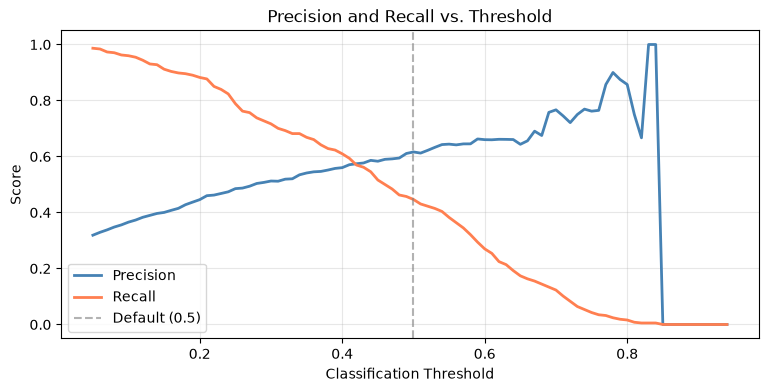

In [9]:
# Visualise precision and recall vs. threshold
thresh_range = np.arange(0.05, 0.95, 0.01)
precisions, recalls = [], []
for t in thresh_range:
    yp = (y_proba >= t).astype(int)
    precisions.append(precision_score(y_test, yp, zero_division=0))
    recalls.append(recall_score(y_test, yp))

plt.figure(figsize=(9, 4))
plt.plot(thresh_range, precisions, color='steelblue', lw=2, label='Precision')
plt.plot(thresh_range, recalls, color='coral', lw=2, label='Recall')
plt.axvline(0.5, color='gray', linestyle='--', alpha=0.6, label='Default (0.5)')
plt.xlabel('Classification Threshold')
plt.ylabel('Score')
plt.title('Precision and Recall vs. Threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
## Exercises

### Exercise 1: Compute Metrics from a Confusion Matrix

A disease screening test produces these results on 1,000 patients:

| | Predicted Negative | Predicted Positive |
|--|---|---|
| **Actual Negative** | 850 | 50 |
| **Actual Positive** | 30 | 70 |

Compute: accuracy, precision, recall, F1 score, and false positive rate.
Then answer: is this model suitable for disease screening? Why or why not?

In [13]:
# TODO: compute the metrics above
tn_ex, fp_ex, fn_ex, tp_ex = 850, 50, 30, 70

accuracy_ex  = (tp_ex + tn_ex) / (tp_ex + tn_ex + fp_ex + fn_ex)
precision_ex = tp_ex / (tp_ex + fp_ex)
recall_ex    = tp_ex / (tp_ex + fn_ex)
f1_ex        = 2 * (precision_ex * recall_ex) / (precision_ex + recall_ex)
fpr_ex       = fp_ex / (fp_ex + tn_ex) 

print(f'Accuracy:            {accuracy_ex:.4f}')
print(f'Precision:           {precision_ex:.4f}')
print(f'Recall:              {recall_ex:.4f}')
print(f'F1:                  {f1_ex:.4f}')
print(f'False Positive Rate: {fpr_ex:.4f}')

Accuracy:            0.9200
Precision:           0.5833
Recall:              0.7000
F1:                  0.6364
False Positive Rate: 0.0556


<details><summary><b>Click for Solution</b></summary>

```python
tn_ex, fp_ex, fn_ex, tp_ex = 850, 50, 30, 70

accuracy_ex  = (tp_ex + tn_ex) / (tp_ex + tn_ex + fp_ex + fn_ex)  # 0.92
precision_ex = tp_ex / (tp_ex + fp_ex)                              # 0.583
recall_ex    = tp_ex / (tp_ex + fn_ex)                              # 0.70
f1_ex        = 2 * precision_ex * recall_ex / (precision_ex + recall_ex)  # 0.636
fpr_ex       = fp_ex / (fp_ex + tn_ex)                              # 0.056
```

**Is this good for disease screening?**
Recall is 70%, which means the model **misses 30% of sick patients** — those go home undiagnosed.
In a medical screening context, false negatives are very costly.
We would want higher recall, even at the cost of lower precision (more false alarms that get a follow-up test).
Lowering the classification threshold would increase recall at the expense of precision.

</details>

### Exercise 2: Find the Threshold that Maximises F1

Using the churn model's predicted probabilities (`y_proba`), find the threshold from 0.1 to 0.9 that produces the highest F1 score on the test set.

In [16]:
# TODO: find the best threshold
thresholds_ex = np.arange(0.1, 0.9, 0.01)

print(f'{'Threshold':>10} {'Precision':>10} {'Recall':>10} {'F1':>8} {'Flagged':>8}')
print('-' * 52)
f1_scores_ex = []
for t in thresholds_ex:
    yp = (y_proba >= t).astype(int)
    p = precision_score(y_test, yp, zero_division=0)
    r = recall_score(y_test, yp)
    f = f1_score(y_test, yp, zero_division=0)
    f1_scores_ex.append(f)
    flagged = yp.sum()
    print(f'{t:>10.2f} {p:>10.4f} {r:>10.4f} {f:>8.4f} {flagged:>8}')

# f1_scores_ex    = None  # Fix this — list of F1 scores, one per threshold
best_thresh_ex  = thresholds_ex[np.argmax(f1_scores_ex)]  # Fix this — threshold with highest F1
best_f1_ex      = f1_scores_ex[np.argmax(f1_scores_ex)]  # Fix this — the highest F1 value

print(f'Best threshold: {best_thresh_ex:.2f}')
print(f'Best F1:        {best_f1_ex:.4f}')
print(f'Default (0.5) F1: {f1_score(y_test, (y_proba >= 0.5).astype(int)):.4f}')

 Threshold  Precision     Recall       F1  Flagged
----------------------------------------------------
      0.10     0.3656     0.9599   0.5295      982
      0.11     0.3730     0.9545   0.5364      957
      0.12     0.3829     0.9439   0.5448      922
      0.13     0.3897     0.9305   0.5493      893
      0.14     0.3966     0.9278   0.5556      875
      0.15     0.4002     0.9118   0.5563      852
      0.16     0.4077     0.9037   0.5619      829
      0.17     0.4148     0.8984   0.5676      810
      0.18     0.4278     0.8957   0.5791      783
      0.19     0.4370     0.8904   0.5863      762
      0.20     0.4459     0.8824   0.5925      740
      0.21     0.4600     0.8770   0.6035      713
      0.22     0.4622     0.8503   0.5989      688
      0.23     0.4680     0.8396   0.6010      671
      0.24     0.4738     0.8235   0.6016      650
      0.25     0.4852     0.7888   0.6008      608
      0.26     0.4872     0.7620   0.5944      585
      0.27     0.4939     0.7

<details><summary><b>Click for Solution</b></summary>

```python
thresholds_ex = np.arange(0.1, 0.9, 0.01)
f1_scores_ex = [f1_score(y_test, (y_proba >= t).astype(int)) for t in thresholds_ex]

best_idx      = np.argmax(f1_scores_ex)
best_thresh_ex = thresholds_ex[best_idx]
best_f1_ex     = f1_scores_ex[best_idx]
```

</details>

### Exercise 3: Interpret a Model's Metrics

A fraud detection model on a test set with 1% fraud produces:
- Accuracy: 0.990
- Precision: 0.35
- Recall: 0.72

Answer the following in your own words:

1. Why does accuracy look so good but precision is only 0.35?
2. What does recall 0.72 mean for the business?
3. Would you lower or raise the classification threshold to catch more fraud? What is the tradeoff?

1. Because fraud is rare, only 1%. Most of them are normal, so the model looks accurate just by saying "not fraud" most of the time.
2. It means the model catches 72% of real fraud and misses 28% which can be expensive (3 in 10 fraud causes still get through).
3. Lower the threshold to catch more fraud.

<details><summary><b>Click for Answers</b></summary>

1. **Accuracy looks good because 99% of transactions are not fraud.** Even a model that always predicts 'not fraud' achieves 99% accuracy. This model's 0.990 accuracy is meaningless as a fraud detection signal.

2. **Recall 0.72 means the model catches 72% of actual fraud** — and misses 28%. Depending on the transaction values at risk, missing 28% of fraud could be a major financial loss.

3. **Lower the threshold** to catch more fraud (increase recall). This will flag more transactions as suspicious (lower precision — more false positives), but in fraud detection, missing fraud is usually more costly than a false alarm. The optimal threshold depends on the cost of each error type.

</details>

---
## What You Should Be Able to Do Now

- Build a confusion matrix and extract TP, TN, FP, FN
- Compute accuracy, precision, recall, F1, and FPR from first principles, and verify with sklearn
- Explain the precision-recall tradeoff and what shifting the threshold does
- Choose an appropriate threshold given a specific business objective (e.g. maximise F1, or prioritise recall)